In [2]:
import pandas as pd

df=pd.read_csv("C:\\Users\\Dell\\Downloads\\matplotlib_messy_sales_2000.csv")
df

,Customer ID,Order Date,City,Product Category,Customer Segment,Gender,Sales Channel,Age,Units Sold,Unit Price,Discount %,Customer Rating,Is Active,Returned,Payment Method,Gross Sales,Discount Amount,Revenue,Cost,Profit
0,CUST00594,2025-05-05 00:00:00,Mumbai,Clothing,premium,Male,Retail,36.0,8,24235.73,22.91,1.9,1,0,UPI,193885.84,44419.25,149466.59,88698.45,60768.14
1,CUST01103,2025-10-22 00:00:00,Mumbai,Clothing,Premium,Female,Corporate,38.0,5,16789.55,10.59,4.3,1,0,Cash,83947.75,8890.07,75057.68,61426.31,13631.37
2,CUST00690,2025-04-24 00:00:00,Delhi,Home & Kitchen,Regular,Male,Retail,65.0,2,24579.97,36.22,4.5,1,0,Debit Card,49159.94,17805.73,31354.21,24948.21,6406.00
3,CUST00215,2025-05-17 00:00:00,Chennai,Electronics,Regular,Male,Corporate,34.0,9,6240.13,20.44,3.9,1,0,Net Banking,56161.17,11479.34,NaN,26470.33,18211.50
4,CUST01270,2025-08-30 00:00:00,Delhi,Clothing,Budget,Female,Corporate,41.0,1,23491.23,10.48,3.7,1,0,Net Banking,23491.23,2461.88,21029.35,12312.38,8716.97
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015,CUST00043,2025-12-17 00:00:00,Pune,Sports,Premium,Male,Retail,24.0,10,9181.27,18.05,3.7,1,0,UPI,91812.70,16572.19,75240.51,39994.75,35245.76
2016,CUST00602,2025-12-22 00:00:00,Pune,Sports,Regular,Female,Retail,44.0,9,6947.94,32.93,1.5,1,0,Cash,62531.46,20591.61,41939.85,33246.33,8693.52
2017,CUST01708,2025-05-28 00:00:00,Hyderabad,Home & Kitchen,Premium,Male,Retail,56.0,5,5393.37,25.19,3.4,1,0,UPI,26966.85,6792.95,20173.90,13654.93,6518.97
2018,CUST00614,2025-08-27 00:00:00,Chennai,Sports,Premium,Male,Online,41.0,7,10803.59,0.5,5.0,1,0,UPI,75625.13,378.13,75247.00,46822.20,28424.80


In [5]:
#1.Column Names
#Display all column names. Identify columns having leading/trailing spaces and
#rename all columns into a consistent snake_case format.


# 1. Display all column names
df.columns.tolist()

# 2. Identify columns having leading/trailing spaces
print("\nColumns with leading/trailing spaces:")
for col in df.columns:
    if col != col.strip():
        print(repr(col))

# 3. Rename all columns to consistent snake_case format
df.columns = (
    df.columns
    .str.strip()                    # Remove leading/trailing spaces
    .str.lower()                    # Convert to lowercase
    .str.replace(r'[^a-z0-9]+', '_', regex=True)  # Replace special chars/spaces
    .str.strip('_')                 # Remove extra underscores
)

# 4. Display cleaned column names
df.columns.tolist()


Columns with leading/trailing spaces:


['customer_id',
 'order_date',
 'city',
 'product_category',
 'customer_segment',
 'gender',
 'sales_channel',
 'age',
 'units_sold',
 'unit_price',
 'discount',
 'customer_rating',
 'is_active',
 'returned',
 'payment_method',
 'gross_sales',
 'discount_amount',
 'revenue',
 'cost',
 'profit']

In [6]:
#2.Duplicate Records
#Find the number of duplicate rows. Remove the duplicate records and verify that no
#duplicates remain.

# 1. Find the number of duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# 2. Remove duplicate rows
df = df.drop_duplicates()

# 3. Verify that no duplicates remain
print("Duplicates remaining:", df.duplicated().sum())

Number of duplicate rows: 20
Duplicates remaining: 0


In [7]:
#3. Missing Values
#Display the missing-value count and missing-value percentage for every column.

# 1. Missing-value count
missing_count = df.isnull().sum()

# 2. Missing-value percentage
missing_percentage = (df.isnull().sum() / len(df)) * 100

# 3. Display count and percentage for every column
missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

print(missing_summary)

                  Missing_Count  Missing_Percentage
customer_id                   0                0.00
order_date                    4                0.20
city                         25                1.25
product_category             24                1.20
customer_segment              0                0.00
gender                        0                0.00
sales_channel                 0                0.00
age                          27                1.35
units_sold                    4                0.20
unit_price                   24                1.20
discount                     28                1.40
customer_rating              25                1.25
is_active                     0                0.00
returned                      0                0.00
payment_method               25                1.25
gross_sales                   0                0.00
discount_amount               0                0.00
revenue                      25                1.25
cost        

In [10]:
#4.Missing Categorical Values
#Handle missing values in city, product_category, and payment_method using an
#appropriate strategy.


# Create an independent copy of DataFrame
df = df.copy()

# Categorical columns
categorical_columns = ['city', 'product_category', 'payment_method']

# Fill missing values with mode
for col in categorical_columns:
    mode_value = df[col].mode()[0]
    df.loc[:, col] = df[col].fillna(mode_value)

# Check missing values
print(df[categorical_columns].isnull().sum())

city                0
product_category    0
payment_method      0
dtype: int64


In [14]:
#5.Missing Numerical Values
#Handle missing values in age, unit_price, discount_pct, customer_rating, and
#revenue. Explain why you selected mean, median, or another method.

# Make a copy
df = df.copy()

# Numerical columns
numerical_columns = [
    'age',
    'unit_price',
    'discount',
    'customer_rating',
    'revenue'
]

# Convert to numeric
for col in numerical_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill missing values with median
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Verify missing values
print(df[numerical_columns].isnull().sum())

age                0
unit_price         0
discount           0
customer_rating    0
revenue            0
dtype: int64


In [15]:
#6.Date Cleaning
#Convert order_date into a proper datetime format. Identify invalid date values and
#handle them appropriately.

# Make a copy
df = df.copy()

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# Count invalid date values
invalid_dates = df['order_date'].isna().sum()

print("Number of invalid/missing dates:", invalid_dates)

# Display invalid dates if needed
print("\nInvalid dates:")
print(df[df['order_date'].isna()])

# Verify data type
print("\nData type:")
print(df['order_date'].dtype)

Number of invalid/missing dates: 25

Invalid dates:
     customer_id order_date       city product_category customer_segment  \
34     CUST00092        NaT       Pune   Home & Kitchen           Budget   
52     CUST00807        NaT  Bengaluru   Home & Kitchen           Budget   
58     CUST01070        NaT     Mumbai   Home & Kitchen          Regular   
187    CUST00750        NaT  Hyderabad           Beauty          Premium   
238    CUST01938        NaT       Pune         Clothing           Budget   
317    CUST00595        NaT      Delhi           Beauty           Budget   
329    CUST00905        NaT      Delhi      Electronics          Premium   
333    CUST01839        NaT     Mumbai   Home & Kitchen          Regular   
347    CUST00751        NaT  Hyderabad           Sports          Premium   
394    CUST01627        NaT  Bengaluru      Electronics          Regular   
582    CUST00822        NaT      Delhi         Clothing          Premium   
670    CUST01154        NaT       Pu

In [16]:
#7.Age Cleaning
#The age column contains values such as 25 years, 30 yrs, 45Y, and N/A. Extract the
#numerical age and convert the column into a numeric datatype.

# Convert age values like '25 years', '30 yrs', '45Y', 'N/A' into numeric
df['age'] = (
    df['age']
    .astype(str)
    .str.extract(r'(\d+(?:\.\d+)?)', expand=False)
)

# Convert extracted values to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Check the result
print(df['age'].head(10))
print("\nData type:", df['age'].dtype)
print("\nMissing ages:", df['age'].isna().sum())

0    36.0
1    38.0
2    65.0
3    34.0
4    41.0
5    49.0
6    29.0
7    46.0
8    61.0
9    25.0
Name: age, dtype: float64

Data type: float64

Missing ages: 0


In [17]:
#8. Age Outliers
#Identify unrealistic ages such as 120, 150, and 200. Detect them using the IQR
#method and handle them appropriately.

# Calculate Q1 and Q3
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers
age_outliers = df[
    (df['age'] < lower_bound) |
    (df['age'] > upper_bound)
]

print("\nAge Outliers:")
print(age_outliers[['age']])
print("\nNumber of outliers:", len(age_outliers))

Q1: 30.0
Q3: 56.0
IQR: 26.0
Lower Bound: -9.0
Upper Bound: 95.0

Age Outliers:
        age
193   150.0
256   120.0
323   120.0
329   200.0
467   120.0
534   200.0
647   120.0
777   150.0
869   150.0
991   150.0
1023  120.0
1532  150.0
1731  120.0
2000  120.0

Number of outliers: 14


In [18]:
#9.Unit Price Cleaning
#The unit_price column contains values such as ₹15000, $20000, 25000 INR, and 10k.
#Convert all valid values into a single numeric format.

# Make a copy
df = df.copy()

# Function to clean unit_price
def clean_price(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().lower()

    # Remove currency symbols and text
    value = value.replace('₹', '')
    value = value.replace('$', '')
    value = value.replace('inr', '')
    value = value.replace(',', '')
    value = value.strip()

    # Handle values ending with 'k'
    if value.endswith('k'):
        value = value[:-1]
        return float(value) * 1000

    # Convert normal numeric values
    return pd.to_numeric(value, errors='coerce')


# Apply cleaning
df['unit_price'] = df['unit_price'].apply(clean_price)

# Check result
print(df['unit_price'].head(10))
print("\nData type:", df['unit_price'].dtype)

0     24235.73
1     16789.55
2     24579.97
3      6240.13
4     23491.23
5      1808.30
6     28497.86
7     23023.33
8    250000.00
9     18649.79
Name: unit_price, dtype: float64

Data type: float64


In [20]:
#10.Unit Price Outliers
#Detect extreme unit_price values using the IQR method. Compare the number of
#outliers before and after treatment.

import numpy as np

# Calculate Q1, Q3 and IQR
Q1 = df['unit_price'].quantile(0.25)
Q3 = df['unit_price'].quantile(0.75)

IQR = Q3 - Q1

# Calculate bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Identify outliers BEFORE treatment
outliers_before = (
    (df['unit_price'] < lower_bound) |
    (df['unit_price'] > upper_bound)
)

print("\nOutliers before treatment:", outliers_before.sum())

# Treat outliers by replacing them with NaN
df.loc[outliers_before, 'unit_price'] = np.nan

# Fill treated values with median
df['unit_price'] = df['unit_price'].fillna(df['unit_price'].median())

# Check outliers AFTER treatment
outliers_after = (
    (df['unit_price'] < lower_bound) |
    (df['unit_price'] > upper_bound)
)

print("Outliers after treatment:", outliers_after.sum())

Q1: 7776.865
Q3: 22614.622499999998
IQR: 14837.757499999998
Lower Bound: -14479.771249999996
Upper Bound: 44871.25874999999

Outliers before treatment: 15
Outliers after treatment: 0


In [21]:
#11.Units Sold Cleaning
#Clean values such as 5 units, 10 pcs, twenty, N/A, and 3 and convert the column into
#a numeric datatype.

import pandas as pd

# Clean Units Sold column
df['units_sold'] = (
    df['units_sold']
    .astype(str)
    .str.lower()
    .str.replace('units', '', regex=False)
    .str.replace('pcs', '', regex=False)
    .str.strip()
)

# Convert words and invalid values
word_map = {
    'twenty': 20,
    'ten': 10,
    'five': 5,
    'three': 3,
    'two': 2,
    'one': 1
}

df['units_sold'] = df['units_sold'].replace(word_map)

# Convert to numeric
df['units_sold'] = pd.to_numeric(df['units_sold'], errors='coerce')

print(df['units_sold'])
print(df['units_sold'].dtype)    

0        8.0
1        5.0
2        2.0
3        9.0
4        1.0
        ... 
2015    10.0
2016     9.0
2017     5.0
2018     7.0
2019    12.0
Name: units_sold, Length: 2000, dtype: float64
float64


In [24]:
#12. Discount Cleaning
#Clean values such as 10%, 20 percent, 5 %, none, and N/A. Convert the final
#discount_pct column into numeric values between 0 and 100.

import pandas as pd

# Clean discount column
df['discount'] = (
    df['discount']
    .astype(str)
    .str.lower()
    .str.replace('%', '', regex=False)
    .str.replace('percent', '', regex=False)
    .str.strip()
)

# Replace invalid values
df['discount'] = df['discount'].replace({
    'none': None,
    'n/a': None,
    'nan': None
})

# Convert to numeric
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

# Keep values between 0 and 100
df['discount'] = df['discount'].clip(0, 100)

print(df['discount'])
print(df['discount'].dtype)

0       22.91
1       10.59
2       36.22
3       20.44
4       10.48
        ...  
2015    18.05
2016    32.93
2017    25.19
2018     0.50
2019    23.29
Name: discount, Length: 2000, dtype: float64
float64


In [25]:
#13.Discount Outliers
#Identify invalid discount values such as 75, 90, and 120. Determine which values are
#unrealistic and handle them.

# Identify suspicious discount values
invalid_discount = df[df['discount'] > 100]

print("Invalid discount values:")
print(invalid_discount[['discount']])

Invalid discount values:
Empty DataFrame
Columns: [discount]
Index: []


In [28]:
#14.City Standardization
#Standardize inconsistent city values such as:
#o Mumbai
#o mumbai
#o MUMBAI
#o Mumbai
#o Bangalore
#o bangalore
#o Hyderbad
#Create one consistent set of city names.


# Convert city names to lowercase and remove extra spaces
df['city'] = df['city'].astype(str).str.strip().str.lower()

# Standardize city names
df['city'] = df['city'].replace({
    'mumbai': 'Mumbai',
    'delhi': 'Delhi',
    'chennai': 'Chennai',
    'hyderabad': 'Hyderabad',
    'pune': 'Pune',
    'bengaluru': 'Bangalore',
    'bangalore': 'Bangalore',
    'hyderbad': 'Hyderabad'
})

# Check unique values
print(df['city'].unique())

['Mumbai' 'Delhi' 'Chennai' 'Hyderabad' 'Pune' 'Bangalore']


In [29]:
#15.Product Category Cleaning
#Standardize values such as Electronics, electronics, ELECTRONICS, Home and Kitchen,
#home & kitchen, and Beauty .

# Clean product category
df['product_category'] = (
    df['product_category']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize category names
df['product_category'] = df['product_category'].replace({
    'electronics': 'Electronics',
    'home and kitchen': 'Home and Kitchen',
    'home & kitchen': 'Home and Kitchen',
    'beauty': 'Beauty'
})

# Check unique values
print(df['product_category'].unique())    

['clothing' 'Home and Kitchen' 'Electronics' 'sports' 'Beauty']


In [31]:
#16.Gender Cleaning
#Standardize values such as Male, male, Male, FEMALE, female , M, and F into
#consistent categories.

# Clean gender values
df['gender'] = (
    df['gender']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize gender categories
df['gender'] = df['gender'].replace({
    'male': 'Male',
    'm': 'Male',
    'female': 'Female',
    'f': 'Female'
})

# Check unique values
df['gender'].unique()

array(['Male', 'Female', 'other'], dtype=object)

In [32]:
#17.Customer Segment Cleaning
#Identify invalid values such as Prem, Reg, VIP, and Unknown. Map valid variations to
#the correct categories and decide how to handle invalid categories.


# Clean customer segment
df['customer_segment'] = (
    df['customer_segment']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Standardize valid variations
df['customer_segment'] = df['customer_segment'].replace({
    'prem': 'Premium',
    'premium': 'Premium',
    'reg': 'Regular',
    'regular': 'Regular',
    'vip': 'VIP'
})

# Handle invalid/unknown values
df['customer_segment'] = df['customer_segment'].replace({
    'unknown': 'Unknown',
    'nan': 'Unknown',
    '': 'Unknown'
})

# Check unique values
print(df['customer_segment'].unique())

['Premium' 'Regular' 'budget']


In [33]:
#18.Binary Column Cleaning
#Clean is_active and returned, where values contain combinations of:
#o 0/1
#o Yes/No
#o Y/N
#o Active/Inactive
#o Returned/Not Returned
#Convert both columns into a consistent 0/1 binary format.

# Convert is_active to 0/1
df['is_active'] = (
    df['is_active']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1,
        'y': 1,
        'true': 1,
        '1': 1,
        'no': 0,
        'n': 0,
        'false': 0,
        '0': 0
    })
)

# Convert returned to 0/1
df['returned'] = (
    df['returned']
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        'yes': 1,
        'y': 1,
        'true': 1,
        '1': 1,
        'no': 0,
        'n': 0,
        'false': 0,
        '0': 0
    })
)

# Convert to numeric
df['is_active'] = pd.to_numeric(df['is_active'], errors='coerce')
df['returned'] = pd.to_numeric(df['returned'], errors='coerce')

print(df[['is_active', 'returned']].head())    

   is_active  returned
0        1.0       0.0
1        1.0       0.0
2        1.0       0.0
3        1.0       0.0
4        1.0       0.0


In [34]:
#19.Data-Type Validation
#After cleaning, display df.info() and verify that:
#o Dates are datetime
#o Numerical columns are numeric
#o Binary columns contain only 0 and 1
#o Categorical columns contain clean strings

# Display DataFrame information
df.info()

# Check date column
print("\nDate datatype:")
print(df['order_date'].dtype)

# Check numerical columns
numeric_columns = [
    'age', 'units_sold', 'unit_price', 'discount',
    'customer_rating', 'gross_sales', 'discount_amount',
    'revenue', 'cost', 'profit'
]

print("\nNumerical column datatypes:")
print(df[numeric_columns].dtypes)

# Check binary columns
print("\nBinary column values:")
print("is_active:", df['is_active'].unique())
print("returned:", df['returned'].unique())

# Check categorical columns
categorical_columns = [
    'city', 'product_category', 'customer_segment',
    'gender', 'sales_channel', 'payment_method'
]

print("\nCategorical columns:")
for col in categorical_columns:
    print(f"{col}: {df[col].dtype}")
    print(df[col].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 0 to 2019
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       2000 non-null   object        
 1   order_date        1975 non-null   datetime64[ns]
 2   city              2000 non-null   object        
 3   product_category  2000 non-null   object        
 4   customer_segment  2000 non-null   object        
 5   gender            2000 non-null   object        
 6   sales_channel     2000 non-null   object        
 7   age               2000 non-null   float64       
 8   units_sold        1996 non-null   float64       
 9   unit_price        2000 non-null   float64       
 10  discount          2000 non-null   float64       
 11  customer_rating   2000 non-null   float64       
 12  is_active         1993 non-null   float64       
 13  returned          1996 non-null   float64       
 14  payment_method    2000 non-nu

In [35]:
#20.Final Data Quality Check — Hardest
#Perform a complete final audit of the cleaned dataset:
#o Check duplicate rows
#o Check missing values
#o Check invalid dates
#o Check numerical columns
#o Check outliers
#o Check categorical inconsistencies
#o Check binary values
#o Check datatypes
#o Verify that Revenue, Cost, and Profit are logically consistent

import pandas as pd
import numpy as np

# ============================================================
# 20. FINAL DATA QUALITY CHECK
# ============================================================

print("=" * 60)
print("FINAL DATA QUALITY AUDIT")
print("=" * 60)

# 1. Check duplicate rows
print("\n1. DUPLICATE ROWS")
print("Number of duplicate rows:", df.duplicated().sum())


# 2. Check missing values
print("\n2. MISSING VALUES")
print(df.isnull().sum())


# 3. Check invalid dates
print("\n3. INVALID DATES")

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(
    df['order_date'],
    errors='coerce'
)

print("Invalid dates:", df['order_date'].isna().sum())


# 4. Check numerical columns
print("\n4. NUMERICAL COLUMNS")

numeric_columns = [
    'age',
    'units_sold',
    'unit_price',
    'discount',
    'customer_rating',
    'gross_sales',
    'discount_amount',
    'revenue',
    'cost',
    'profit'
]

print(df[numeric_columns].dtypes)

# Check non-numeric values
for col in numeric_columns:
    invalid = pd.to_numeric(df[col], errors='coerce').isna().sum()
    print(f"{col}: {invalid} invalid values")


# 5. Check outliers using IQR
print("\n5. OUTLIER CHECK")

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    print(
        f"{col}: {len(outliers)} outliers "
        f"(Lower={lower_bound:.2f}, Upper={upper_bound:.2f})"
    )


# 6. Check categorical inconsistencies
print("\n6. CATEGORICAL VALUES")

categorical_columns = [
    'city',
    'product_category',
    'customer_segment',
    'gender',
    'sales_channel',
    'payment_method'
]

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].dropna().unique())


# 7. Check binary values
print("\n7. BINARY VALUES")

binary_columns = [
    'is_active',
    'returned'
]

for col in binary_columns:
    values = df[col].dropna().unique()

    print(f"{col}: {values}")

    invalid = set(values) - {0, 1}

    if len(invalid) == 0:
        print("Status: Valid")
    else:
        print("Invalid values:", invalid)


# 8. Check datatypes
print("\n8. DATA TYPES")
print(df.dtypes)


# 9. Verify Revenue, Cost and Profit
print("\n9. REVENUE, COST AND PROFIT CONSISTENCY")

# Expected profit = Revenue - Cost
df['expected_profit'] = df['revenue'] - df['cost']

# Difference between actual and expected profit
df['profit_difference'] = (
    df['profit'] - df['expected_profit']
)

# Check rows where profit is inconsistent
inconsistent_profit = df[
    ~np.isclose(
        df['profit'],
        df['expected_profit'],
        equal_nan=True
    )
]

print("Inconsistent profit rows:",
      len(inconsistent_profit))

# Check Revenue
print(
    "Revenue < 0:",
    (df['revenue'] < 0).sum()
)

# Check Cost
print(
    "Cost < 0:",
    (df['cost'] < 0).sum()
)

# Check Profit calculation
print(
    "Profit = Revenue - Cost:",
    np.isclose(
        df['profit'],
        df['revenue'] - df['cost'],
        equal_nan=True
    ).all()
)


# 10. Final summary
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())
print("Invalid dates:", df['order_date'].isna().sum())
print(
    "Binary values valid:",
    all(
        set(df[col].dropna().unique()).issubset({0, 1})
        for col in binary_columns
    )
)
print(
    "Profit calculation valid:",
    np.isclose(
        df['profit'],
        df['revenue'] - df['cost'],
        equal_nan=True
    ).all()
)

FINAL DATA QUALITY AUDIT

1. DUPLICATE ROWS
Number of duplicate rows: 0

2. MISSING VALUES
customer_id          0
order_date          25
city                 0
product_category     0
customer_segment     0
gender               0
sales_channel        0
age                  0
units_sold           4
unit_price           0
discount             0
customer_rating      0
is_active            7
returned             4
payment_method       0
gross_sales          0
discount_amount      0
revenue              0
cost                 0
profit               0
dtype: int64

3. INVALID DATES
Invalid dates: 25

4. NUMERICAL COLUMNS
age                float64
units_sold         float64
unit_price         float64
discount           float64
customer_rating    float64
gross_sales        float64
discount_amount    float64
revenue            float64
cost               float64
profit             float64
dtype: object
age: 0 invalid values
units_sold: 4 invalid values
unit_price: 0 invalid values
discount: 0 in

 # Matplotlib — 15 Visualization Questions

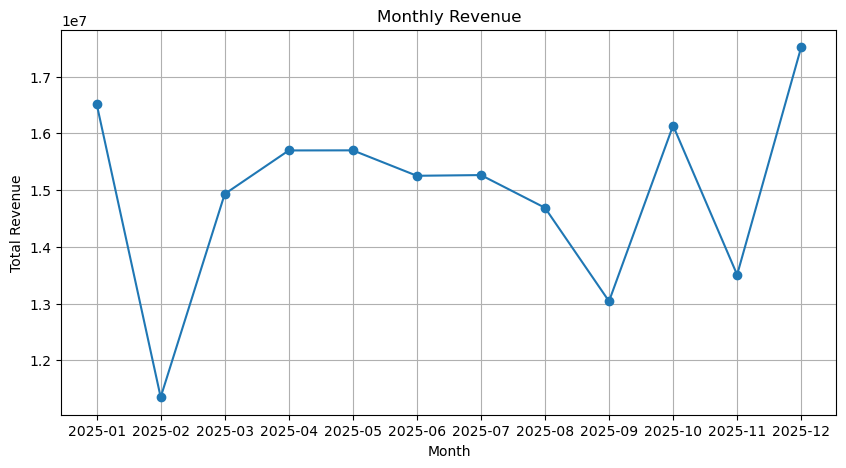

In [36]:
#1.Monthly Revenue Line Chart
#Using order_date and revenue:
#• Convert order_date to datetime.
#• Calculate total revenue for each month.
#• Create a line chart.
#• Add:
#o Title
#o X-axis label
#o Y-axis label
#o Grid
#o Markers
#Commands/concepts: plt.plot(), plt.title(), plt.xlabel(), plt.ylabel(), plt.grid()


import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate total revenue for each month
monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

# Convert period to string for plotting
monthly_revenue.index = monthly_revenue.index.astype(str)

# Create line chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

# Add title and labels
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Total Revenue')

# Add grid
plt.grid(True)

# Display chart
plt.show()

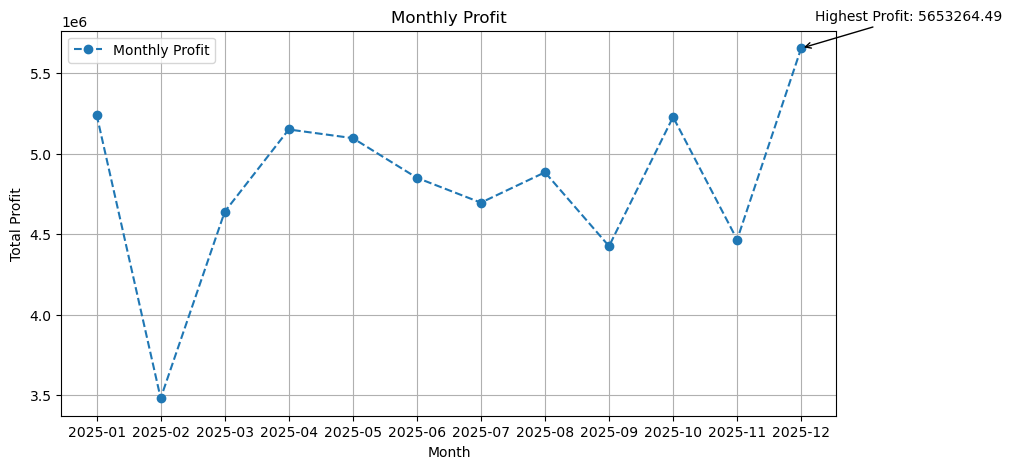

In [37]:
#2.Monthly Profit Line Chart
#Create a line chart showing monthly Profit.
#Requirements:
#• Use a different line style.
#• Add markers.
#• Add a legend.
#• Display the value of the highest-profit month using annotate().
#Commands/concepts: plt.plot(), plt.legend(), plt.annotate()

import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate monthly profit
monthly_profit = df.groupby(
    df['order_date'].dt.to_period('M')
)['profit'].sum()

# Convert index to string
monthly_profit.index = monthly_profit.index.astype(str)

# Find highest-profit month
highest_month = monthly_profit.idxmax()
highest_profit = monthly_profit.max()

# Create line chart
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    linestyle='--',
    marker='o',
    label='Monthly Profit'
)

# Title and labels
plt.title('Monthly Profit')
plt.xlabel('Month')
plt.ylabel('Total Profit')

# Add legend
plt.legend()

# Add annotation
plt.annotate(
    f'Highest Profit: {highest_profit:.2f}',
    xy=(highest_month, highest_profit),
    xytext=(10, 20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

# Add grid
plt.grid(True)

plt.show()

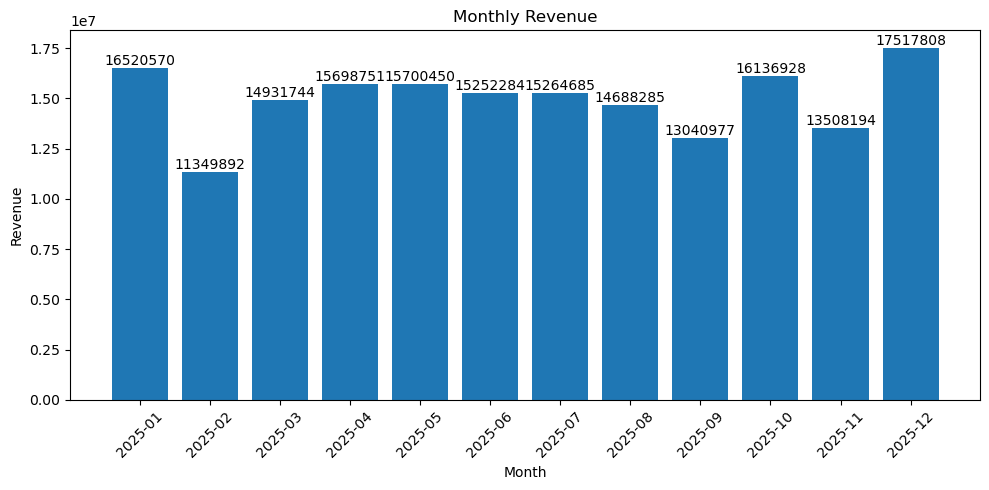

In [38]:
#3.Revenue by Product Category — Bar Chart
#Calculate total revenue for each product_category.
#Create a bar chart.
#Requirements:
#• X-axis → Product Category
#• Y-axis → Revenue
#• Add title and labels.
#• Display the revenue value above each bar.
#Commands/concepts: plt.bar(), plt.text()

import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate monthly revenue
monthly_revenue = df.groupby(
    df['order_date'].dt.to_period('M')
)['revenue'].sum()

# Convert month to string
months = monthly_revenue.index.astype(str)

# Create bar chart
plt.figure(figsize=(10, 5))

plt.bar(months, monthly_revenue.values)

# Title and labels
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')

# Display revenue value above each bar
for i, value in enumerate(monthly_revenue.values):
    plt.text(
        i,
        value,
        f'{value:.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

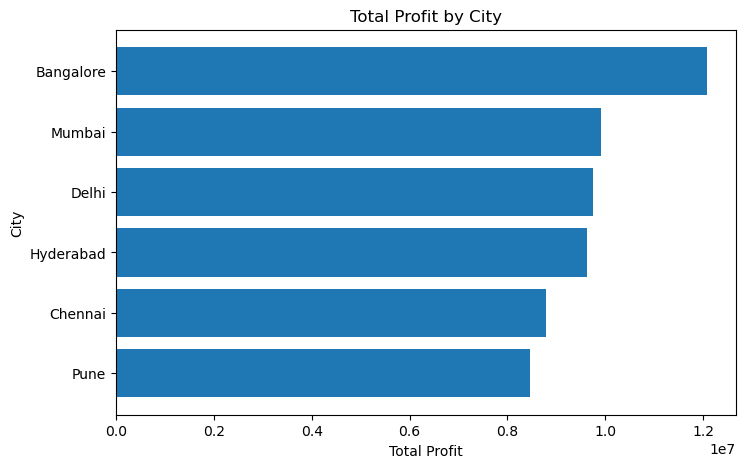

In [41]:
#4.Profit by City — Horizontal Bar Chart
#Calculate total profit for each city.
#Create a horizontal bar chart.
#Requirements:
#• Sort cities by profit.
#• Show the highest-profit city first.
#• Add title and axis labels.
#Commands/concepts: plt.barh(), sort_values()

import matplotlib.pyplot as plt

# Calculate total profit for each city
city_profit = df.groupby('city')['profit'].sum()

# Sort cities by profit (highest first)
city_profit = city_profit.sort_values(ascending=False)

# Create horizontal bar chart
plt.figure(figsize=(8, 5))
plt.barh(city_profit.index, city_profit.values)

# Show highest-profit city first
plt.gca().invert_yaxis()

# Title and axis labels
plt.title('Total Profit by City')
plt.xlabel('Total Profit')
plt.ylabel('City')

plt.show()

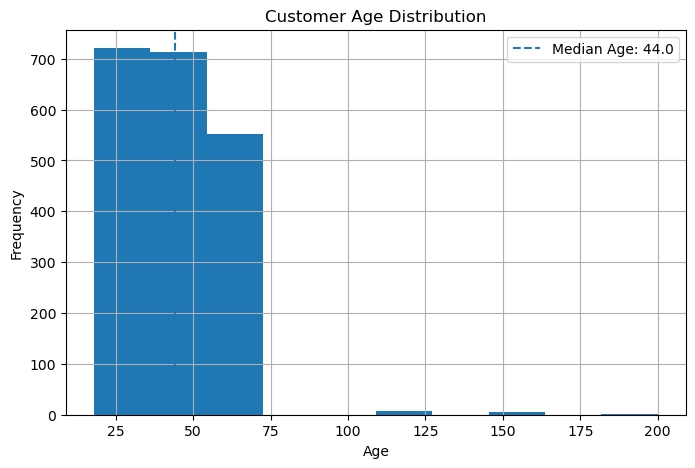

In [42]:
#5.Customer Age Histogram
#Create a histogram of the age column.
#Requirements:
#• Use 10 bins.
#• Add title.
#• Add X/Y labels.
#• Add grid.
#• Add a vertical line showing the median age.
#Commands/concepts: plt.hist(), plt.axvline()

import matplotlib.pyplot as plt

# Calculate median age
median_age = df['age'].median()

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=10)

# Add vertical line for median
plt.axvline(median_age, linestyle='--',
            label=f'Median Age: {median_age:.1f}')

# Title and labels
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Add grid and legend
plt.grid(True)
plt.legend()

plt.show()

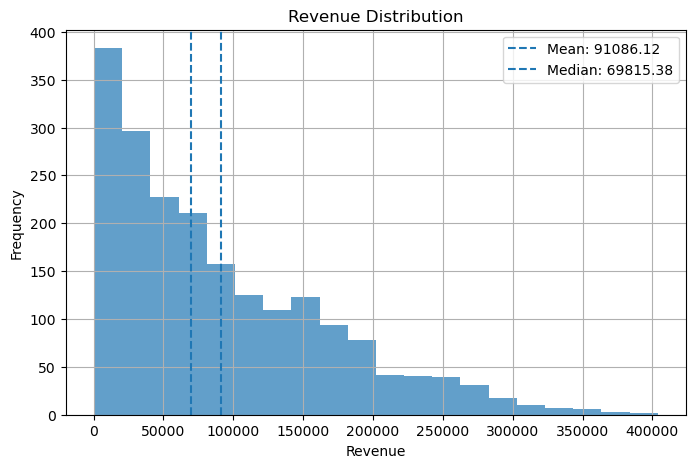

In [43]:
#6.Revenue Distribution Histogram
#Create a histogram showing the distribution of revenue.
#Requirements:
#• Use 20 bins.
#• Add transparency using alpha.
#• Add grid.
#• Add mean and median lines.
#• Add a legend.
#Commands/concepts:
#plt.hist()
#plt.axvline()
#plt.legend()

import matplotlib.pyplot as plt

# Calculate mean and median
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(df['revenue'], bins=20, alpha=0.7)

# Add mean line
plt.axvline(mean_revenue, linestyle='--',
            label=f'Mean: {mean_revenue:.2f}')

# Add median line
plt.axvline(median_revenue, linestyle='--',
            label=f'Median: {median_revenue:.2f}')

# Title and labels
plt.title('Revenue Distribution')
plt.xlabel('Revenue')
plt.ylabel('Frequency')

# Add grid and legend
plt.grid(True)
plt.legend()

plt.show()

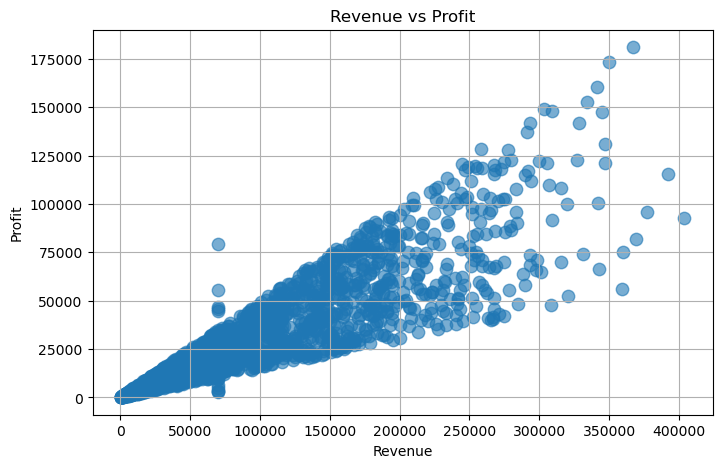

In [44]:
#7.Revenue vs Profit Scatter Plot
#Create a scatter plot between:
#• X → Revenue
#• Y → Profit
#Requirements:
#• Use different marker size.
#• Add transparency.
#• Add title and axis labels.
#• Add grid.
#Commands/concepts:
#plt.scatter()
#Important parameters to practice:
#s=
#alpha=
#marker=

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df['revenue'],
    df['profit'],
    s=80,          # marker size
    alpha=0.6,     # transparency
    marker='o'     # marker style
)

plt.title('Revenue vs Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')

plt.grid(True)

plt.show()

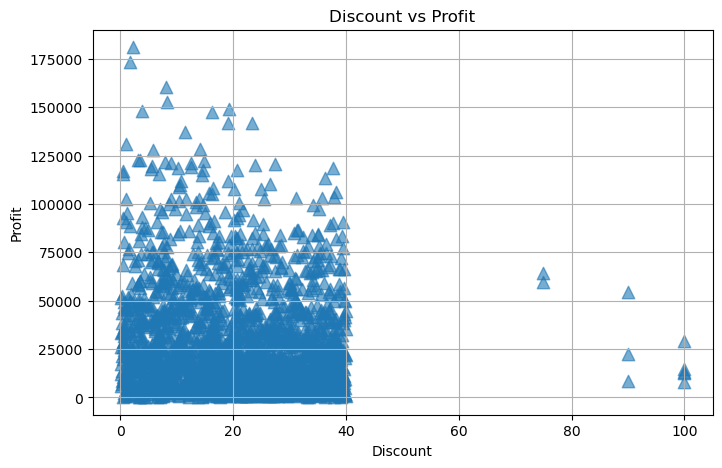

In [45]:
#8. Discount vs Profit Scatter Plot
#Create a scatter plot between:
#• X → discount_pct
#• Y → profit
#Requirements:
#• Use a different marker.
#• Add transparency.
#• Add title.
#• Add axis labels.
#• Add grid.
#Then answer:
#Does profit appear to decrease as discount increases?

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df['discount'],
    df['profit'],
    s=80,
    alpha=0.6,
    marker='^'
)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True)

plt.show()

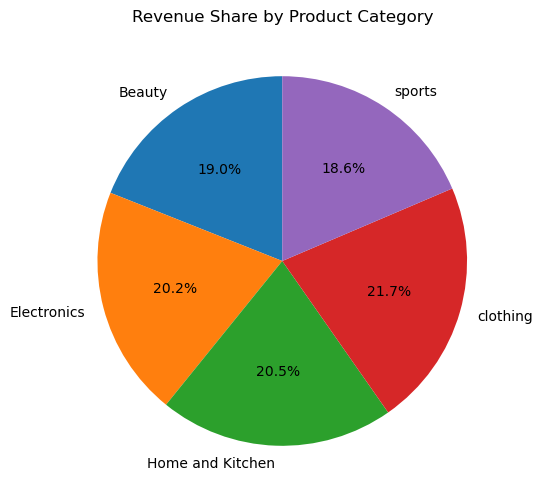

In [46]:
#9.Revenue Share — Pie Chart
#Calculate total revenue for every product_category.
#Create a pie chart showing each category's contribution.
#Requirements:
#• Display percentages.
#• Display category names.
#• Add a title.
#• Start the first slice from the top.
#Commands/concepts:
#plt.pie()
#Important parameters:
#autopct=
#startangle=
#labels=

import matplotlib.pyplot as plt

# Calculate total revenue for each product category
category_revenue = df.groupby('product_category')['revenue'].sum()

# Create pie chart
plt.figure(figsize=(8, 6))

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Revenue Share by Product Category')

plt.show()

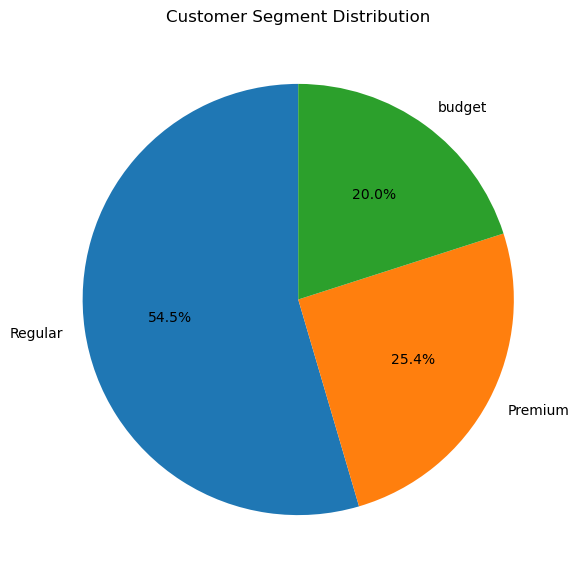

In [47]:
#10.Customer Segment Pie Chart
#Create a pie chart showing the number of customers/orders in each customer segment.
#Segments:
#• Regular
#• Budget
#Requirements:
#• Show percentage.
#• Add labels.
#• Add title.
#• Make the chart visually clean.
#Question: Which customer segment has the largest share?

import matplotlib.pyplot as plt

# Count customers in each segment
segment_counts = df['customer_segment'].value_counts()

# Create pie chart
plt.figure(figsize=(7, 7))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Segment Distribution')

plt.show()

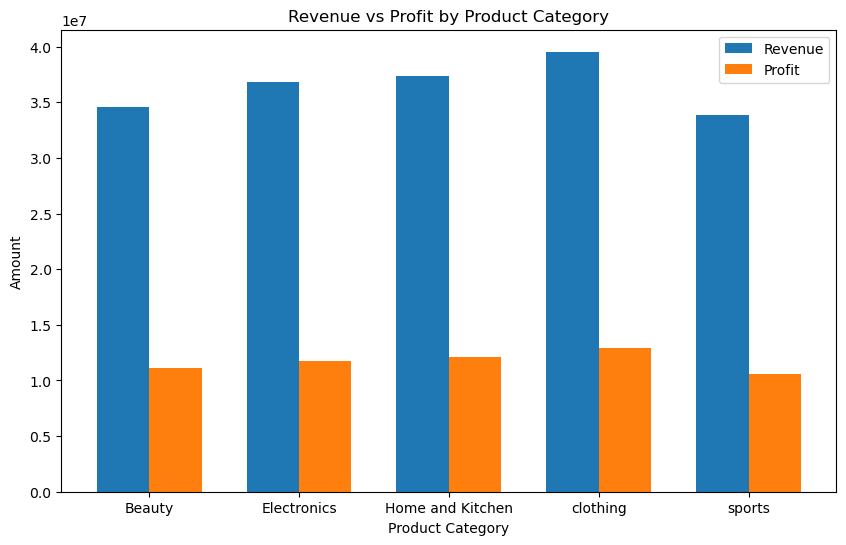

In [48]:
#11. Compare Revenue and Profit
#Create a grouped bar chart for each product_category.
#For every category show:
#• Revenue
#• Profit
#Requirements:
#• Two bars per category.
#• Different colors.
#• Add legend.
#• Add title and axis labels.
#Concepts: plt.bar(), bar positions, width, plt.xticks()

import matplotlib.pyplot as plt
import numpy as np

# Calculate total revenue and profit for each product category
category_data = df.groupby('product_category')[['revenue', 'profit']].sum()

# Categories and positions
categories = category_data.index
x = np.arange(len(categories))

# Bar width
width = 0.35

# Create grouped bar chart
plt.figure(figsize=(10, 6))

plt.bar(x - width/2, category_data['revenue'],
        width=width, label='Revenue')

plt.bar(x + width/2, category_data['profit'],
        width=width, label='Profit')

# Labels and title
plt.title('Revenue vs Profit by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Amount')

# Category names on X-axis
plt.xticks(x, categories)

# Legend
plt.legend()

plt.show()

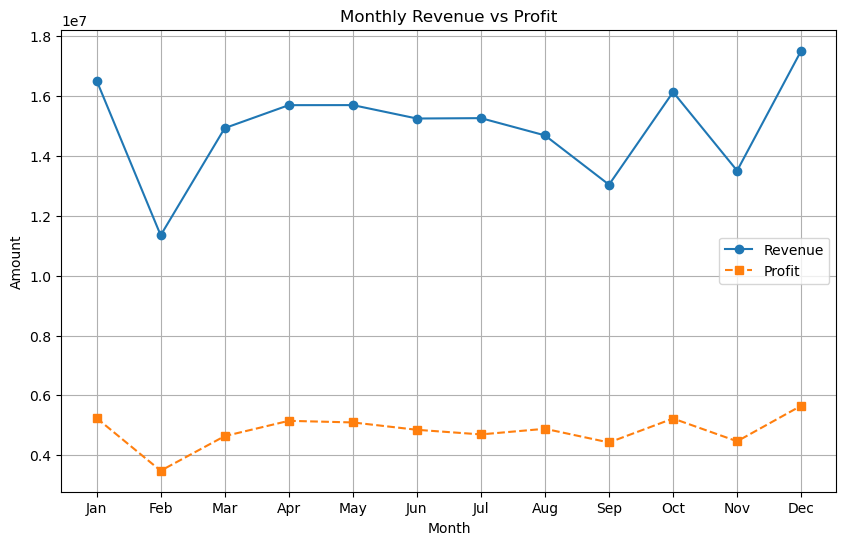

In [49]:
#12. Monthly Revenue vs Profit
#Create a chart containing two lines:
#• Revenue
#• Profit
#for every month.
#Requirements:
#• Different colors.
#• Different markers.
#• Different line styles.
#• Legend.
#• Grid.
#• Title.
#• X/Y labels.
#Example concept:
#plt.plot(months, revenue)
#plt.plot(months, profit)

import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create month column
df['month'] = df['order_date'].dt.month

# Calculate monthly revenue and profit
monthly_data = df.groupby('month')[['revenue', 'profit']].sum()

# Sort by month
monthly_data = monthly_data.sort_index()

# Month names
months = pd.to_datetime(monthly_data.index, format='%m').strftime('%b')

# Plot Revenue
plt.figure(figsize=(10, 6))

plt.plot(
    months,
    monthly_data['revenue'],
    marker='o',
    linestyle='-',
    label='Revenue'
)

# Plot Profit
plt.plot(
    months,
    monthly_data['profit'],
    marker='s',
    linestyle='--',
    label='Profit'
)

# Title and labels
plt.title('Monthly Revenue vs Profit')
plt.xlabel('Month')
plt.ylabel('Amount')

# Grid and legend
plt.grid(True)
plt.legend()

plt.show()

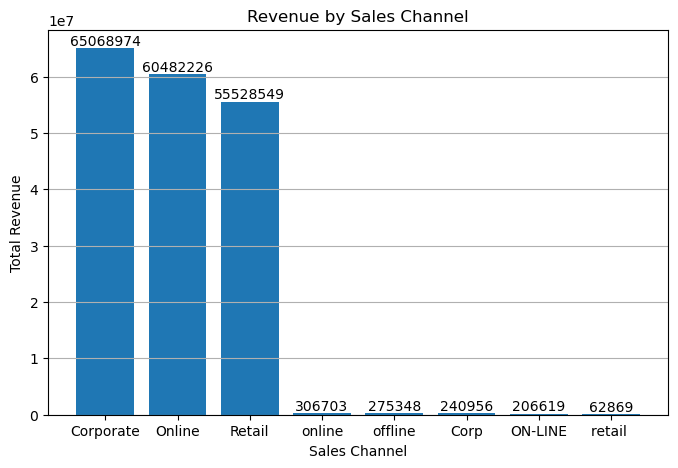

Highest Revenue Channel: Corporate


In [50]:
#13. Sales Channel Comparison
#Calculate total revenue for:
#• Online
#• Retail
#• Corporate
#Create a bar chart.
#Requirements:
#• Add value labels on bars.
#• Sort from highest to lowest.
#• Add title.
#• Add axis labels.
#• Add grid.
#Question: Which sales channel generates the highest revenue?

import matplotlib.pyplot as plt

# Calculate total revenue by sales channel
channel_revenue = df.groupby('sales_channel')['revenue'].sum()

# Sort from highest to lowest
channel_revenue = channel_revenue.sort_values(ascending=False)

# Create bar chart
plt.figure(figsize=(8, 5))

bars = plt.bar(
    channel_revenue.index,
    channel_revenue.values
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Revenue')

plt.grid(axis='y')
plt.show()

# Find highest revenue channel
print("Highest Revenue Channel:", channel_revenue.idxmax())

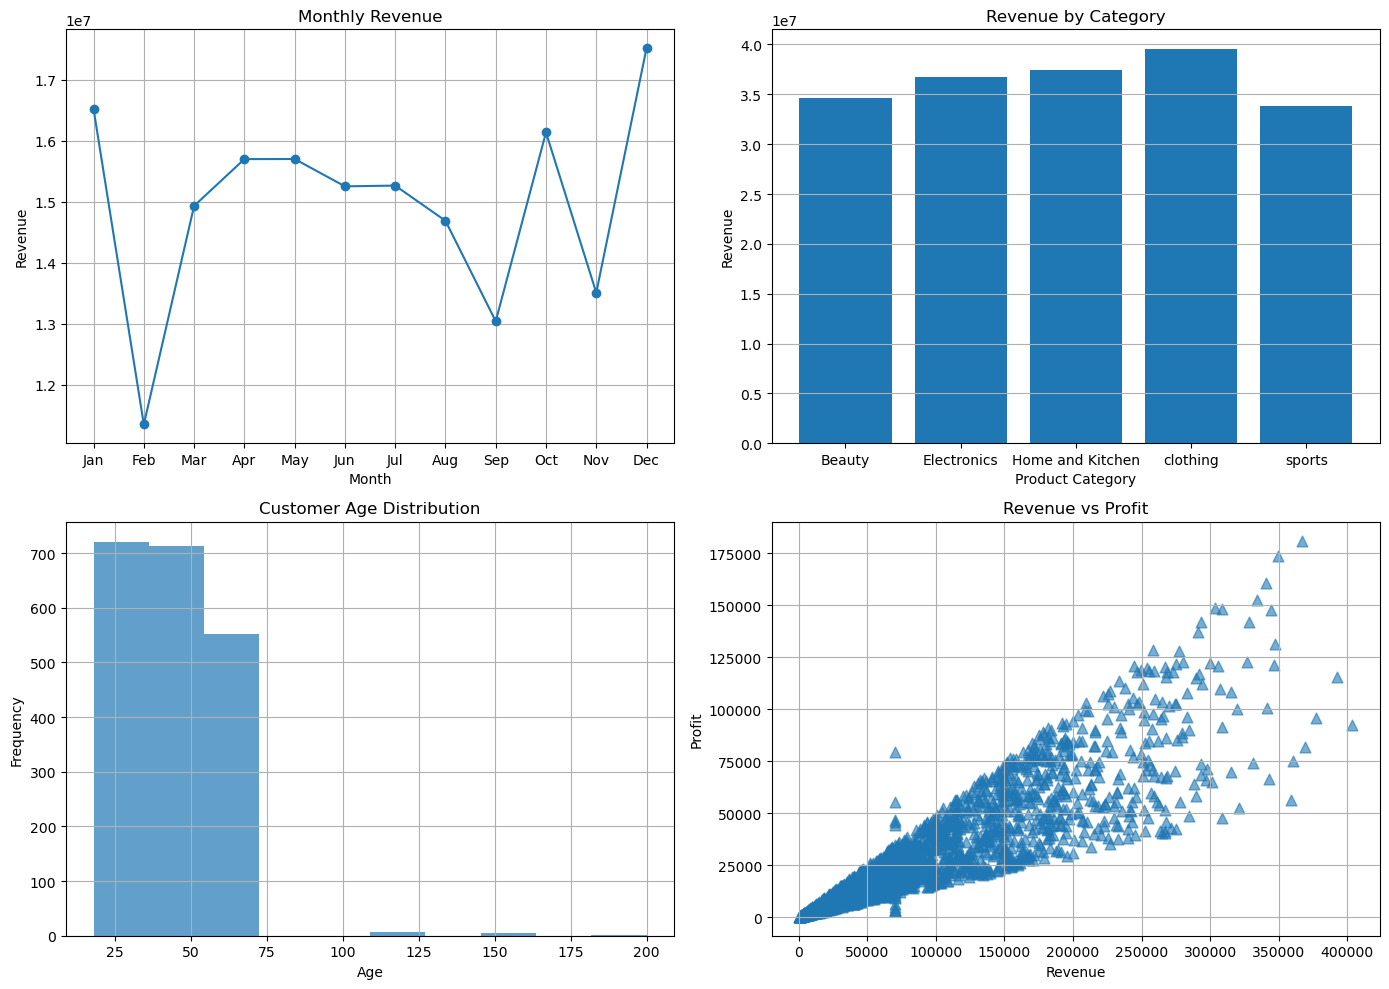

In [51]:
#14.Four-Chart Matplotlib Dashboard
#Create a 2 × 2 subplot.
#Chart 1
#Monthly Revenue → Line chart
#Chart 2
#Revenue by Category → Bar chart
#Chart 3
#Customer Age → Histogram
#Chart 4
#Revenue vs Profit → Scatter plot
#Use:
#plt.subplots(2, 2)
#Give every subplot:
#• Its own title
#• Appropriate labels
#• Grid where useful
#Finally use:
#plt.tight_layout()



import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create month column
df['month'] = df['order_date'].dt.month

# Monthly revenue
monthly_revenue = df.groupby('month')['revenue'].sum().sort_index()

# Month names
months = pd.to_datetime(
    monthly_revenue.index, format='%m'
).strftime('%b')

# Revenue by product category
category_revenue = df.groupby('product_category')['revenue'].sum()


# Create 2 × 2 subplot
fig, ax = plt.subplots(2, 2, figsize=(14, 10))


# Chart 1: Monthly Revenue — Line Chart
ax[0, 0].plot(
    months,
    monthly_revenue.values,
    marker='o'
)

ax[0, 0].set_title('Monthly Revenue')
ax[0, 0].set_xlabel('Month')
ax[0, 0].set_ylabel('Revenue')
ax[0, 0].grid(True)


# Chart 2: Revenue by Category — Bar Chart
ax[0, 1].bar(
    category_revenue.index,
    category_revenue.values
)

ax[0, 1].set_title('Revenue by Category')
ax[0, 1].set_xlabel('Product Category')
ax[0, 1].set_ylabel('Revenue')
ax[0, 1].grid(axis='y')


# Chart 3: Customer Age — Histogram
ax[1, 0].hist(
    df['age'],
    bins=10,
    alpha=0.7
)

ax[1, 0].set_title('Customer Age Distribution')
ax[1, 0].set_xlabel('Age')
ax[1, 0].set_ylabel('Frequency')
ax[1, 0].grid(True)


# Chart 4: Revenue vs Profit — Scatter Plot
ax[1, 1].scatter(
    df['revenue'],
    df['profit'],
    s=60,
    alpha=0.6,
    marker='^'
)

ax[1, 1].set_title('Revenue vs Profit')
ax[1, 1].set_xlabel('Revenue')
ax[1, 1].set_ylabel('Profit')
ax[1, 1].grid(True)


# Adjust spacing
plt.tight_layout()

plt.show()

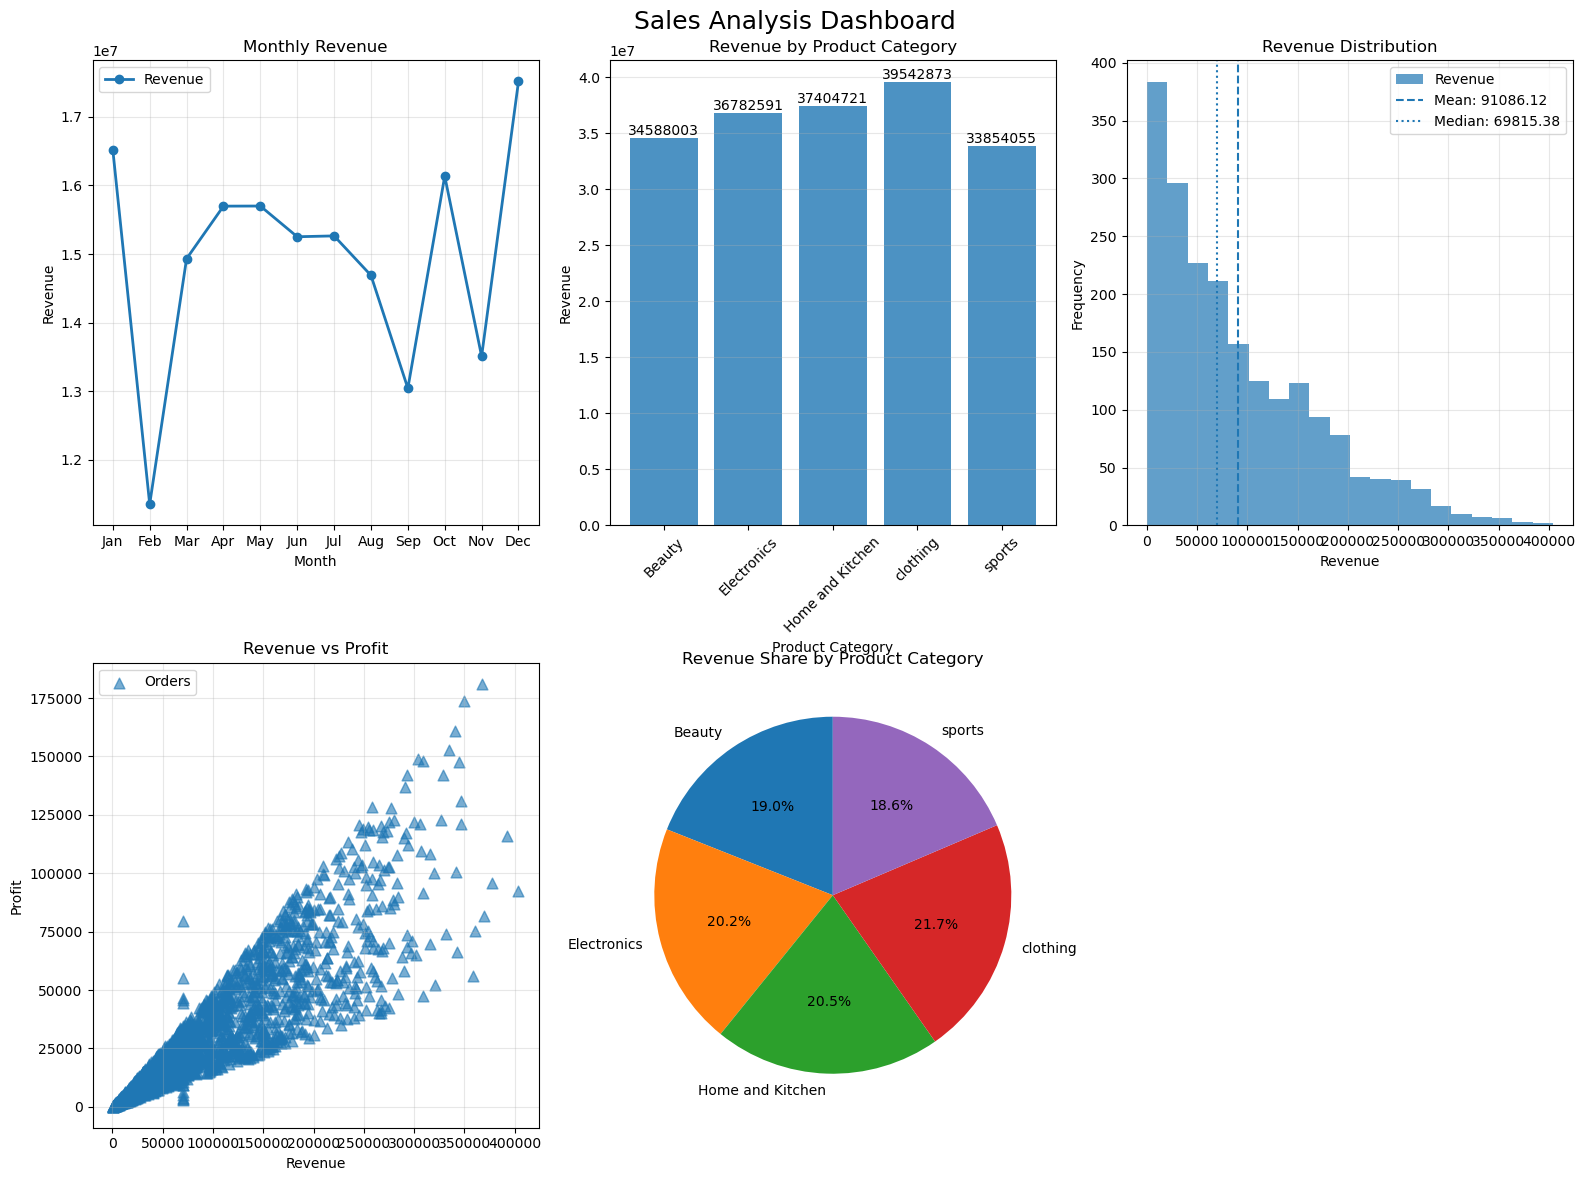

In [53]:
#15.Final Exam Question — Sales Analysis
#Using the complete dataset, create a professional Matplotlib visualization containing:
#Chart 1: Monthly Revenue → Line chart
#Chart 2: Category Revenue → Bar chart
#Chart 3: Revenue Distribution → Histogram
#Chart 4: Revenue vs Profit → Scatter plot
#Chart 5: Category Revenue Share → Pie chart
#For the visual design:
#• Add appropriate colors
#• Use markers where appropriate
#• Add legends
#• Add grid
#• Add titles
#• Add X/Y labels
#• Use alpha for transparency where appropriate
#• Add value labels to bars
#• Add percentage labels to pie chart
#• Use figsize
#• Use tight_layout()


import pandas as pd
import matplotlib.pyplot as plt

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Create month column
df['month'] = df['order_date'].dt.month

# Calculate monthly revenue
monthly_revenue = df.groupby('month')['revenue'].sum().sort_index()

# Month names
months = pd.to_datetime(
    monthly_revenue.index,
    format='%m'
).strftime('%b')

# Calculate revenue by category
category_revenue = df.groupby('product_category')['revenue'].sum()


# Create figure with 5 charts
fig = plt.figure(figsize=(16, 12))

# Chart 1: Monthly Revenue - Line Chart
ax1 = plt.subplot(2, 3, 1)

ax1.plot(
    months,
    monthly_revenue.values,
    marker='o',
    linewidth=2,
    label='Revenue'
)

ax1.set_title('Monthly Revenue')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue')
ax1.grid(True, alpha=0.3)
ax1.legend()


# Chart 2: Category Revenue - Bar Chart
ax2 = plt.subplot(2, 3, 2)

bars = ax2.bar(
    category_revenue.index,
    category_revenue.values,
    alpha=0.8
)

ax2.set_title('Revenue by Product Category')
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Revenue')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{bar.get_height():.0f}',
        ha='center',
        va='bottom'
    )


# Chart 3: Revenue Distribution - Histogram
ax3 = plt.subplot(2, 3, 3)

ax3.hist(
    df['revenue'],
    bins=20,
    alpha=0.7,
    label='Revenue'
)

# Mean and median
mean_revenue = df['revenue'].mean()
median_revenue = df['revenue'].median()

ax3.axvline(
    mean_revenue,
    linestyle='--',
    label=f'Mean: {mean_revenue:.2f}'
)

ax3.axvline(
    median_revenue,
    linestyle=':',
    label=f'Median: {median_revenue:.2f}'
)

ax3.set_title('Revenue Distribution')
ax3.set_xlabel('Revenue')
ax3.set_ylabel('Frequency')
ax3.grid(True, alpha=0.3)
ax3.legend()


# Chart 4: Revenue vs Profit - Scatter Plot
ax4 = plt.subplot(2, 3, 4)

ax4.scatter(
    df['revenue'],
    df['profit'],
    s=60,
    alpha=0.6,
    marker='^',
    label='Orders'
)

ax4.set_title('Revenue vs Profit')
ax4.set_xlabel('Revenue')
ax4.set_ylabel('Profit')
ax4.grid(True, alpha=0.3)
ax4.legend()



# Chart 5: Category Revenue Share - Pie Chart
ax5 = plt.subplot(2, 3, 5)

ax5.pie(
    category_revenue.values,
    labels=category_revenue.index,
    autopct='%1.1f%%',
    startangle=90
)

ax5.set_title('Revenue Share by Product Category')


# Overall title
fig.suptitle(
    'Sales Analysis Dashboard',
    fontsize=18
)

# Adjust layout
plt.tight_layout()

plt.show()